# NIJ データを使ったセミ合成データ実験

計画: `plans/semisynthetic_nij.md`（改訂版、承認済み）

**目的**: 元論文の主張（MJCA 型の予測 $\hat q(x)=\hat E[r\mid x]$ は処遇 $a$ の影響によるバイアスを含み、それが誤った処遇判断につながる）を、NIJ の実際の $x$ の分布・相関・処遇割当て（overlap）の上で確かめる。実データでは反事実アウトカムが分からないので、**潜在的な結果だけを人工的に作る**。

**生成過程**（既存シミュレーション §4.2 と同じ構造）:

| 要素 | 本実験 |
|---|---|
| $x$ | NIJ の実際の 56 変数（方策入力と同じ。標準化） |
| $a$ | Georgia の実際の割当て（High/Specialized = 1） |
| 割当ての方向 $\beta$ | 実際の割当てを 56 変数でロジスティック回帰した係数を、元シミュレーションと同じ尺度（$\text{SD}(\beta^\top x)=8.8$）に定数倍 |
| 潜在的な結果 | $z_0=\gamma_0^\top x+\varepsilon$、$z_1=\gamma_1^\top x+\varepsilon$、$\gamma_0=\alpha_0\odot\beta$（$\alpha_0\sim U(0,2)$）、$\gamma_1=-\alpha_1\odot\beta$（$\alpha_1\sim U(0,1.5)$）、$\varepsilon\sim N(0,\sigma^2)$、$r(a)\sim\text{Bernoulli}(\sigma(z_a))$ |

処遇されやすい人（$\beta^\top x$ が大きい）ほど、処遇されなければ高リスクで、処遇されればリスクが下がる。観測データでは処遇の効果で低リスクに見えるので、MJCA 型はこの人たちを処遇しなくなる。**これが MJCA のバイアス**。

- **段階 1**: 上の生成過程で、MJCA 型のバイアスと、DM・DR-OPL の頑健性を示す（サンプルサイズ・ノイズを既存シミュレーションと同じように振る）
- **段階 2**: 少数の解釈しやすい変数による異質性を明示的に加え、DR-OPL がそれを復元できるかを SHAP で確かめる

In [1]:
# @title 0. パスとパッケージ
import os, sys, pickle, random
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

sns.set_style("ticks")
sns.set_context("paper")
pd.set_option('display.width', 200)
# macOS では LightGBM と PyTorch の OpenMP が衝突してハングするため、PyTorch を 1 スレッドにする
torch.set_num_threads(1)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    ROOT = Path('/content/commentary_mjca')
    if not ROOT.exists():
        import subprocess
        subprocess.run(['git', 'clone', 'https://github.com/MasaAsami/commentary_mjca.git', str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROC_CSV = ROOT / 'data/processed/nij_analysis_sample.csv'
assert PROC_CSV.exists(), '先に notebooks/nij_georgia_analysis.ipynb を実行して分析サンプルを作ってください'
OUT = Path(os.environ.get('SEMISYNTH_OUT', ROOT / 'outputs/nij_semisynth'))  # 動作確認時は環境変数で出力先を変える
OUT.mkdir(parents=True, exist_ok=True)

NUM_REPS = int(os.environ.get('NUM_REPS', 1000))        # 段階 1 の各条件の回数（既存シミュレーションと同じ 1,000）
NUM_REPS_HET = int(os.environ.get('NUM_REPS_HET', 200))  # 段階 2 の回数
SEED = 42
C_BLUE, C_ORANGE, C_AQUA, C_GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#7a7974'
print('NUM_REPS =', NUM_REPS, '| NUM_REPS_HET =', NUM_REPS_HET, '| output ->', OUT)

NUM_REPS = 1000 | NUM_REPS_HET = 200 | output -> /Users/hdymacuser/Develop/commentary_mjca/outputs/nij_semisynth


/private/tmp/claude-503/-Users-hdymacuser-Develop-commentary-mjca/9d919d7f-ae99-427e-8be6-6b9d30517715/scratchpad/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# @title 1. データと、割当ての方向 β
data = pd.read_csv(PROC_CSV)
NON_X = {'level', 'A', 'train', 'ID', 'e_cf'} | {c for c in data.columns if c.startswith('Recidivism')}
X_ALL = [c for c in data.columns if c not in NON_X]
X_POL = [c for c in X_ALL if c not in ('black', 'risk_score', 'risk_score_missing')]
Xraw = data[X_POL].values.astype(float)
Z_ALL = (Xraw - Xraw.mean(axis=0)) / np.where(Xraw.std(axis=0) > 0, Xraw.std(axis=0), 1)
A_ALL = data['A'].values.astype(int)

beta_hat = LogisticRegression(max_iter=5000).fit(Z_ALL, A_ALL).coef_[0]
TARGET_SD = 8.8  # 元シミュレーションの SD(β'x)（52 次元・n=6,000、5 seed の平均 8.77）
scale = TARGET_SD / (Z_ALL @ beta_hat).std()
BETA = beta_hat * scale
print(f'n = {len(data)}, 変数 {len(X_POL)} | SD(x·β̂) = {(Z_ALL @ beta_hat).std():.3f} → 定数倍 {scale:.2f} | SD(x·β) = {(Z_ALL @ BETA).std():.2f}')
print('AUC of x·β̂ for the real assignment:', round(roc_auc_score(A_ALL, Z_ALL @ beta_hat), 3))
beta_tab = pd.Series(BETA, index=X_POL).sort_values(key=np.abs, ascending=False)
beta_tab.round(3).to_csv(OUT / 'beta_direction.csv')
display(beta_tab.head(10).round(3))

n = 24115, 変数 56 | SD(x·β̂) = 1.286 → 定数倍 6.84 | SD(x·β) = 8.80
AUC of x·β̂ for the real assignment: 0.756


age_group                        -5.991
offense_Violent_Sex               5.397
prison_years                      2.978
offense_Missing                  -1.460
Prior_Arrest_Episodes_Felony      1.419
offense_Drug                     -1.076
Condition_Other                   0.872
Prior_Revocations_Parole          0.763
Prior_Conviction_Episodes_Prop    0.746
Prior_Conviction_Episodes_Drug    0.673
dtype: float64

In [3]:
# @title 2. 段階 2 の明示的な異質性 h(x)（設計者が決める「正解」の変数）
HET_VARS = {'age_group': -1.0, 'Condition_MH_SA': 1.0, 'Prior_Arrest_Episodes_Drug': 1.0}
HET_IDX = np.array([X_POL.index(v) for v in HET_VARS])
HET_W = np.array(list(HET_VARS.values()))
_h_raw = Z_ALL[:, HET_IDX] @ HET_W
H_MU, H_SD = _h_raw.mean(), _h_raw.std()

def h_fn(Z):
    # 若い・MH/SA 条件あり・薬物関連の逮捕歴が多いほど大きい（処遇で再犯が大きく下がる）
    return (Z[:, HET_IDX] @ HET_W - H_MU) / H_SD

SIGMA_REAL = 10   # 現実的なノイズ: 結果モデルの AUC が実データ（0.733）と同じになる σ（計画 §8）
KAPPA_HET = 10.0  # SD(κ h) = 10（段階 2 の条件 σ = 10 と同じ大きさ）
print('SD(κ h) =', round((KAPPA_HET * h_fn(Z_ALL)).std(), 2), '| corr(h, x·β) =', round(np.corrcoef(h_fn(Z_ALL), Z_ALL @ BETA)[0, 1], 3))

SD(κ h) = 10.0 | corr(h, x·β) = 0.107


## 3. 手法（既存シミュレーション `mjca_simdata_fixed.ipynb` の修正版と同じ実装・設定）

- nuisance（$\hat\pi_0$, $\hat q(x,a)$）と MJCA 型の $\hat q(x)$: LightGBM（既存と同じ設定）。train 全体で学習し、$\hat\pi_0$ は $[0.05, 0.95]$ で clip
- Policy 1: MJCA 型。閾値はデータから決める
  - 主: **容量一致**（train の観測処遇割合と同じ割合を処遇）
  - 参考: **事後的に最も有利な閾値**（test で 0.05 刻みに動かし、真の方策価値が最も良いもの）と、元論文の **0.2**
- Policy 2: DM $\arg\min_a \hat q(x,a)$
- Policy 3: DR-OPL（NN、不具合修正版の DR 方策勾配。既存と同じく 1 回の学習）
- Policy 0: 最適方策 $r_i(1)<r_i(0)$ なら処遇（既存と同じ定義）。方策の再犯率は、実現した潜在的な結果 $r_i(1), r_i(0)$ で計算する（既存と同じ）

In [4]:
# @title 3-1. 部品
LGB_PARAMS = {'objective': 'binary', 'metric': 'binary_logloss', 'verbosity': -1, 'seed': SEED, 'num_threads': 1}

def fit_lgb(Xm, y):
    return lgb.train(LGB_PARAMS, lgb.Dataset(Xm, y), num_boost_round=100)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

class PolicyNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 2), nn.Softmax(dim=1))

    def forward(self, x):
        return self.fc(x)

def train_dr_policy(Z, A, R, e, q0, q1, num_epochs=100, batch_size=256, seed=0):
    # mjca_simdata_fixed.ipynb の DRPolicyOptimizerFixed と同じ（修正 1: 並べ替えの対応、修正 2: π0(a_i|x_i)）
    set_seed(seed)
    net = PolicyNetwork(Z.shape[1])
    opt = optim.Adam(net.parameters(), lr=0.01)
    X0 = torch.tensor(Z, dtype=torch.float)
    A0 = torch.tensor(A, dtype=torch.long)
    R0 = torch.tensor(R, dtype=torch.float)
    ec = torch.clamp(torch.tensor(e, dtype=torch.float), 0.05, 0.95)
    P0 = torch.where(A0 == 1, ec, 1 - ec)
    Q1, Q0 = torch.tensor(q1, dtype=torch.float), torch.tensor(q0, dtype=torch.float)
    QA = torch.where(A0 == 1, Q1, Q0)
    n = len(A)
    for epoch in range(num_epochs):
        perm = torch.tensor(np.random.permutation(n))
        X_t, A_t, R_t, P_t, Q1_t, Q0_t, QA_t = (t[perm] for t in (X0, A0, R0, P0, Q1, Q0, QA))
        for i in range(int(np.ceil(n / batch_size))):
            sl = slice(i * batch_size, min((i + 1) * batch_size, n))
            opt.zero_grad()
            pi = net(X_t[sl])
            pi_a = pi.gather(1, A_t[sl].view(-1, 1)).squeeze(1)
            V = ((pi_a / P_t[sl]) * (R_t[sl] - QA_t[sl]) + pi[:, 1] * Q1_t[sl] + pi[:, 0] * Q0_t[sl]).mean()
            V.backward()
            opt.step()
    return net

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

THR_GRID = np.round(np.arange(0.05, 0.951, 0.05), 2)

def fit_outcome(Xm, y, outcome_model='lgb'):
    # アウトカムモデル: 'lgb'（既定、表現力が強い）または 'logit'（主効果のみのロジスティック回帰。§6 の誤設定の条件）
    if outcome_model == 'lgb':
        m = fit_lgb(Xm, y)
        return m.predict
    m = LogisticRegression(max_iter=5000).fit(Xm, y)
    return lambda Zm: m.predict_proba(Zm)[:, 1]

In [5]:
# @title 3-2. 1 回分のシミュレーション
def run_once(Z_all, A_all, beta, n, sigma, rep, kappa=0.0, diagnostics=False, return_models=False, outcome_model='lgb'):
    torch.set_num_threads(1)
    rng = np.random.default_rng([rep, n, int(10 * sigma), int(10 * kappa)])
    idx = rng.choice(len(A_all), n, replace=False)
    Z, A = Z_all[idx], A_all[idx]
    # 潜在的な結果（既存シミュレーションと同じ構造。α は回ごとに引き直す）
    alpha0 = rng.uniform(0, 2, len(beta)); alpha1 = rng.uniform(0, 1.5, len(beta))
    gamma0, gamma1 = alpha0 * beta, -alpha1 * beta
    eps = rng.normal(0, sigma, n)
    z0 = Z @ gamma0 + eps
    z1 = Z @ gamma1 - kappa * h_fn(Z) + eps
    R0, R1 = rng.binomial(1, sigmoid(z0)), rng.binomial(1, sigmoid(z1))
    R = np.where(A == 1, R1, R0)

    itr, ite = train_test_split(np.arange(n), test_size=0.3, random_state=rep)
    Ztr, Atr, Rtr, Zte, Ate = Z[itr], A[itr], R[itr], Z[ite], A[ite]
    R0te, R1te = R0[ite], R1[ite]

    # nuisance（train 全体。既存と同じ）
    m_ps = fit_lgb(Ztr, Atr)  # 傾向スコアは常に LightGBM
    m_q = fit_outcome(np.column_stack([Ztr, Atr]), Rtr, outcome_model)
    m_mjca = fit_outcome(Ztr, Rtr, outcome_model)
    qa = lambda Zm, a: m_q(np.column_stack([Zm, np.full(len(Zm), a)]))
    e_tr = np.clip(m_ps.predict(Ztr), 0.05, 0.95)
    q0_tr, q1_tr = qa(Ztr, 0), qa(Ztr, 1)
    bs = max(200, min(2000, n // 10))
    net = train_dr_policy(Ztr, Atr, Rtr, e_tr, q0_tr, q1_tr, batch_size=bs, seed=rep)
    with torch.no_grad():
        p_opl = net(torch.tensor(Zte, dtype=torch.float)).numpy()[:, 1]

    s_tr, s_te = m_mjca(Ztr), m_mjca(Zte)
    q0_te, q1_te = qa(Zte, 0), qa(Zte, 1)
    k_treat = Atr.mean()
    v = lambda d: np.mean(np.where(d == 1, R1te, R0te))
    pol = {
        'Optimal': (R1te < R0te).astype(int),
        'Observed (pi0)': Ate,
        'MJCA': (s_te >= np.quantile(s_tr, 1 - k_treat)).astype(int),
        'MJCA (thr 0.2)': (s_te >= 0.2).astype(int),
        'DM': (q1_te < q0_te).astype(int),
        'DR-OPL': (p_opl >= 0.5).astype(int),
    }
    out = {'n': n, 'sigma': sigma, 'kappa': kappa, 'rep': rep, 'outcome_model': outcome_model}
    for k_, d in pol.items():
        out[f'V_{k_}'] = v(d)
        out[f'share_{k_}'] = d.mean()
    thr_vals = [v((s_te >= t).astype(int)) for t in THR_GRID]
    out['V_MJCA (best thr)'] = min(thr_vals)
    out['best_thr'] = THR_GRID[int(np.argmin(thr_vals))]
    out['AUC_MJCA'] = roc_auc_score(R[ite], s_te)
    out['AUC_DM'] = roc_auc_score(R[ite], np.where(Ate == 1, q1_te, q0_te))
    out['AUC_ps'] = roc_auc_score(Ate, m_ps.predict(Zte))

    if diagnostics:
        # (i) 傾向スコアの 10 分位ごとの、リスク推定と真の「処遇しなかった場合のリスク」
        e_te = m_ps.predict(Zte)
        dec = np.minimum((pd.Series(e_te).rank(pct=True).values * 10).astype(int), 9)
        p0_true = sigmoid(Zte @ gamma0 + eps[ite])
        p1_true = sigmoid(Zte @ gamma1 - kappa * h_fn(Zte) + eps[ite])
        diag = pd.DataFrame({'decile': dec, 'q_MJCA': s_te, 'q_DM0': q0_te, 'q_DM1': q1_te,
                             'p0_true': p0_true, 'p1_true': p1_true, 'r_obs': R[ite], 'A': Ate}).groupby('decile').mean()
        out['diag'] = diag
        # (ii) 係数の符号（Appendix B）: r ~ x（MJCA 型）と、untreated のみで r ~ x（q(x,0) の推定）を真の γ0 と比べる
        lr_mjca = LogisticRegression(max_iter=5000).fit(Ztr, Rtr).coef_[0]
        lr_q0 = LogisticRegression(max_iter=5000).fit(Ztr[Atr == 0], Rtr[Atr == 0]).coef_[0]
        big = np.abs(gamma0) >= np.quantile(np.abs(gamma0), 0.5)  # 真の効果が大きい半分の変数で評価
        out['signflip_MJCA'] = np.mean(np.sign(lr_mjca[big]) != np.sign(gamma0[big]))
        out['signflip_q0'] = np.mean(np.sign(lr_q0[big]) != np.sign(gamma0[big]))
        out['corr_MJCA_gamma0'] = np.corrcoef(lr_mjca, gamma0)[0, 1]
        out['corr_q0_gamma0'] = np.corrcoef(lr_q0, gamma0)[0, 1]
    if return_models:
        out['models'] = dict(net=net, m_mjca=m_mjca, m_q=m_q, gamma0=gamma0, gamma1=gamma1, Zte=Zte, Ztr=Ztr, kappa=kappa, sigma=sigma)
    return out

## 4. 段階 1: MJCA 型のバイアスと、DM・DR-OPL の頑健性

In [6]:
# @title 4-1. 実行（既存シミュレーションと同じ条件）
SAMPLE_SIZES = [500, 2000, 4000, 6000, 8000, 10000]
NOISE_ORIG = [3, 4, 5, 6, 7]      # 元シミュレーションと同じ（再現）
NOISE_REAL = [8, 10, 12, 15, 20]  # 現実的なノイズ（σ = 10 が実データの予測の難しさ）とその感度分析
conds = sorted({(n, 5) for n in SAMPLE_SIZES} | {(6000, s) for s in NOISE_ORIG} |
               {(n, SIGMA_REAL) for n in SAMPLE_SIZES} | {(6000, s) for s in NOISE_REAL})
DIAG_CONDS = {(6000, 5), (6000, SIGMA_REAL)}
jobs = [(n, s, rep) for n, s in conds for rep in range(NUM_REPS)]
print('conditions:', len(conds), '| jobs:', len(jobs))

def cached(path, n_reps, cond_cols, expected):
    # 同じ条件・同じ回数の結果が保存済みなら再利用する（RECOMPUTE=1 で強制的に再計算）
    if os.environ.get('RECOMPUTE') == '1' or not path.exists():
        return None
    df = pd.read_pickle(path)
    got = set(map(tuple, df[cond_cols].drop_duplicates().values.tolist()))
    if got == set(map(tuple, expected)) and df.groupby(cond_cols).size().eq(n_reps).all():
        print('cached:', path.name)
        return df
    return None

res1 = cached(OUT / 'stage1_results.pkl', NUM_REPS, ['n', 'sigma'], conds)
if res1 is not None and (OUT / 'stage1_diagnostics.pkl').exists():
    diag_list = pickle.load(open(OUT / 'stage1_diagnostics.pkl', 'rb'))
else:
    results = Parallel(n_jobs=-1, batch_size=8)(
        delayed(run_once)(Z_ALL, A_ALL, BETA, n, s, rep, diagnostics=((n, s) in DIAG_CONDS))
        for n, s, rep in tqdm(jobs, dynamic_ncols=True))
    diag_list = [(r['sigma'], r.pop('diag')) for r in results if 'diag' in r]
    res1 = pd.DataFrame(results)
    res1.to_pickle(OUT / 'stage1_results.pkl')
    pickle.dump(diag_list, open(OUT / 'stage1_diagnostics.pkl', 'wb'))
res1.shape

conditions: 20 | jobs: 20000
cached: stage1_results.pkl


(20000, 25)

In [7]:
# @title 4-2. 表: 方策の再犯率と最適方策との差（中央値 [2.5%, 97.5%]）
POLS = ['MJCA', 'MJCA (best thr)', 'MJCA (thr 0.2)', 'DM', 'DR-OPL', 'Observed (pi0)']
for p_ in POLS:
    res1[f'gap_{p_}'] = res1[f'V_{p_}'] - res1['V_Optimal']

def fmt(g, col):
    return f"{g[col].median():.3f} [{g[col].quantile(0.025):.3f}, {g[col].quantile(0.975):.3f}]"

rows = []
for (n, s), g in res1.groupby(['n', 'sigma']):
    row = {'n': n, 'sigma': s, 'V*': f"{g['V_Optimal'].median():.3f}"}
    row.update({p_: fmt(g, f'gap_{p_}') for p_ in POLS})
    rows.append(row)
tab1 = pd.DataFrame(rows)
tab1.to_csv(OUT / 'table_stage1_gap.csv', index=False)
display(tab1)
share1 = res1.groupby(['n', 'sigma'])[[f'share_{p_}' for p_ in ['Optimal', 'MJCA', 'DM', 'DR-OPL', 'Observed (pi0)']] + ['best_thr']].median().round(3)
share1.to_csv(OUT / 'table_stage1_shares.csv')
display(share1)
auc1 = res1.groupby(['n', 'sigma'])[['AUC_MJCA', 'AUC_DM', 'AUC_ps']].median().round(3)
auc1.to_csv(OUT / 'table_stage1_auc.csv')
display(auc1)

,n,sigma,V*,MJCA,MJCA (best thr),MJCA (thr 0.2),DM,DR-OPL,Observed (pi0)
0,500,5,0.220,"0.273 [0.147, 0.407]","0.220 [0.127, 0.327]","0.273 [0.147, 0.407]","0.073 [0.027, 0.140]","0.093 [0.046, 0.160]","0.153 [0.093, 0.240]"
1,500,10,0.313,"0.180 [0.087, 0.280]","0.140 [0.067, 0.227]","0.180 [0.087, 0.280]","0.067 [0.020, 0.133]","0.080 [0.033, 0.133]","0.100 [0.047, 0.160]"
2,2000,5,0.223,"0.290 [0.168, 0.400]","0.238 [0.148, 0.340]","0.290 [0.170, 0.402]","0.040 [0.020, 0.068]","0.042 [0.023, 0.063]","0.157 [0.108, 0.208]"
3,2000,10,0.312,"0.185 [0.105, 0.270]","0.153 [0.093, 0.237]","0.188 [0.110, 0.268]","0.038 [0.017, 0.067]","0.042 [0.023, 0.063]","0.100 [0.065, 0.148]"
4,4000,5,0.223,"0.292 [0.164, 0.409]","0.239 [0.151, 0.344]","0.296 [0.182, 0.405]","0.033 [0.017, 0.053]","0.033 [0.022, 0.048]","0.157 [0.116, 0.206]"
5,4000,10,0.315,"0.183 [0.107, 0.270]","0.153 [0.098, 0.240]","0.193 [0.122, 0.269]","0.032 [0.016, 0.051]","0.033 [0.022, 0.048]","0.097 [0.068, 0.142]"
6,6000,3,0.174,"0.366 [0.207, 0.484]","0.294 [0.190, 0.398]","0.368 [0.222, 0.470]","0.031 [0.016, 0.049]","0.029 [0.019, 0.043]","0.192 [0.137, 0.242]"
7,6000,4,0.198,"0.324 [0.183, 0.452]","0.262 [0.171, 0.368]","0.329 [0.207, 0.441]","0.029 [0.015, 0.050]","0.029 [0.020, 0.042]","0.174 [0.129, 0.222]"
8,6000,5,0.225,"0.288 [0.151, 0.409]","0.236 [0.145, 0.340]","0.292 [0.176, 0.398]","0.028 [0.014, 0.047]","0.029 [0.020, 0.041]","0.155 [0.117, 0.208]"
9,6000,6,0.249,"0.255 [0.138, 0.384]","0.216 [0.128, 0.321]","0.265 [0.161, 0.372]","0.028 [0.013, 0.045]","0.029 [0.019, 0.042]","0.140 [0.104, 0.188]"


share_Optimal  share_MJCA  share_DM  share_DR-OPL  share_Observed (pi0)  best_thr
n     sigma                                                                                   
500   5              0.260       0.720     0.433         0.440                 0.587     0.500
      10             0.167       0.733     0.413         0.433                 0.587     0.450
2000  5              0.253       0.717     0.445         0.458                 0.585     0.700
      10             0.172       0.733     0.447         0.450                 0.585     0.550
4000  5              0.256       0.657     0.459         0.468                 0.587     0.750
      10             0.170       0.668     0.452         0.455                 0.587     0.550
6000  3              0.306       0.626     0.464         0.473                 0.586     0.800
      4              0.276       0.628     0.459         0.472                 0.586     0.800
      5              0.252       0.628     0.461         0.469                 0.586     0.750
      6              0.231       0.631     0.464         0.471                 0.586     0.700
      7              0.212       0.630     0.458         0.464                 0.586     0.650
      8              0.199       0.632     0.459         0.462                 0.585     0.525
      10             0.173       0.634     0.458         0.459                 0.586     0.550
      12             0.153       0.636     0.453         0.456                 0.586     0.500
      15             0.127       0.640     0.449         0.448                 0.586     0.550
      20             0.102       0.640     0.444         0.442                 0.586     0.550
8000  5              0.254       0.613     0.463         0.470                 0.585     0.700
      10             0.174       0.619     0.460         0.462                 0.586     0.500
10000 5              0.255       0.605     0.468         0.475                 0.586     0.700
      10             0.171       0.610     0.459         0.459                 0.586     0.550

AUC_MJCA  AUC_DM  AUC_ps
n     sigma                          
500   5         0.588   0.706   0.674
      10        0.551   0.597   0.676
2000  5         0.629   0.799   0.718
      10        0.582   0.669   0.716
4000  5         0.647   0.822   0.737
      10        0.597   0.694   0.737
6000  3         0.690   0.898   0.745
      4         0.670   0.863   0.746
      5         0.660   0.831   0.746
      6         0.646   0.804   0.745
      7         0.634   0.775   0.745
      8         0.624   0.752   0.745
      10        0.605   0.706   0.746
      12        0.589   0.674   0.746
      15        0.571   0.632   0.746
      20        0.552   0.592   0.745
8000  5         0.665   0.839   0.751
      10        0.612   0.717   0.752
10000 5         0.673   0.845   0.755
      10        0.614   0.720   0.755

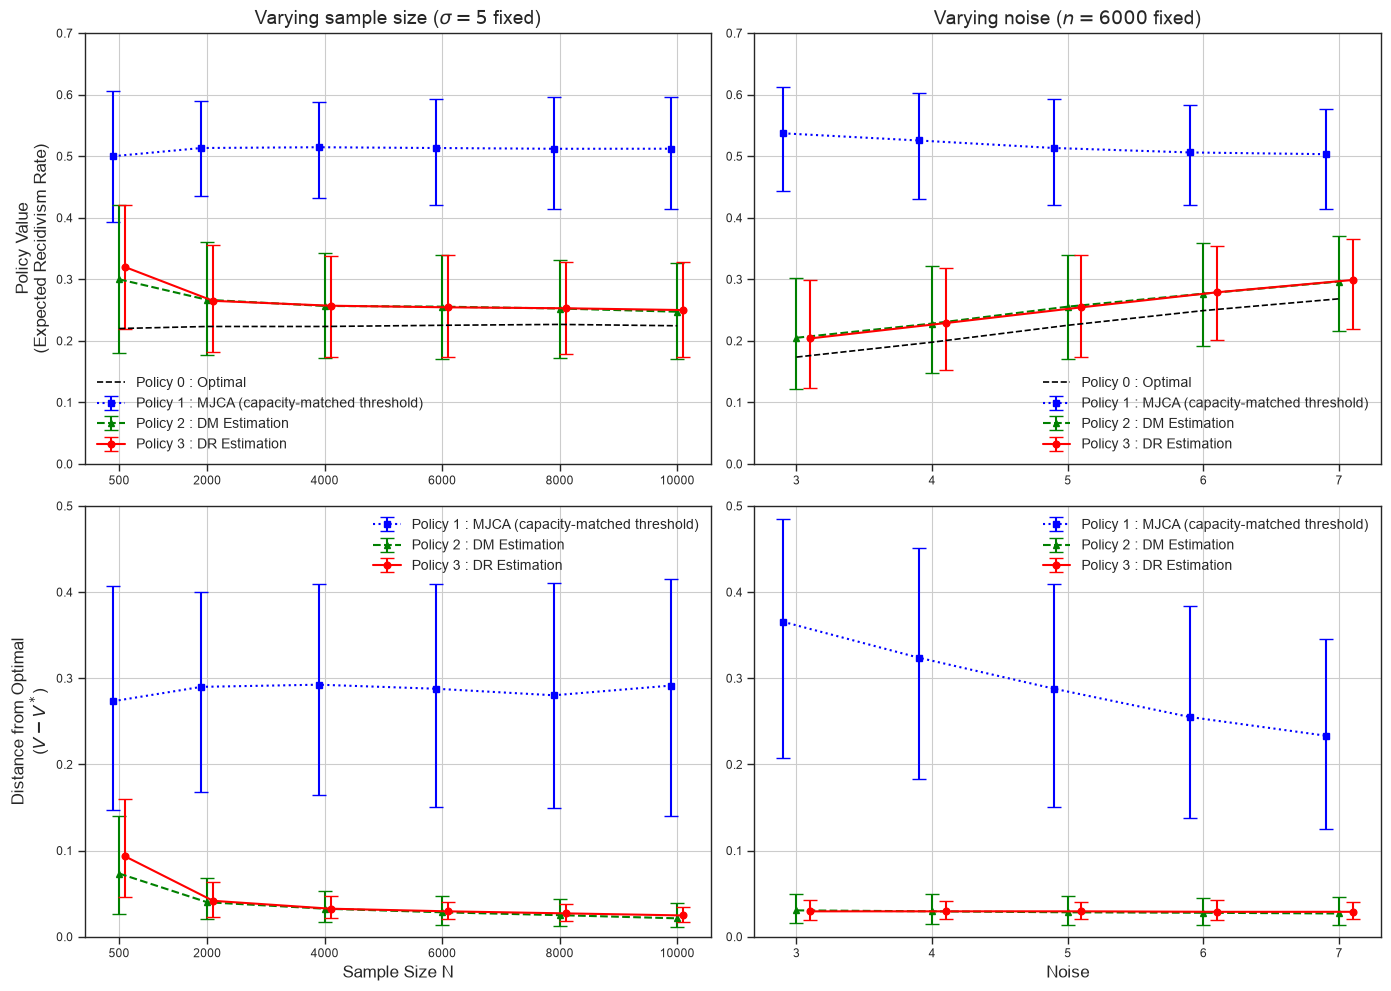

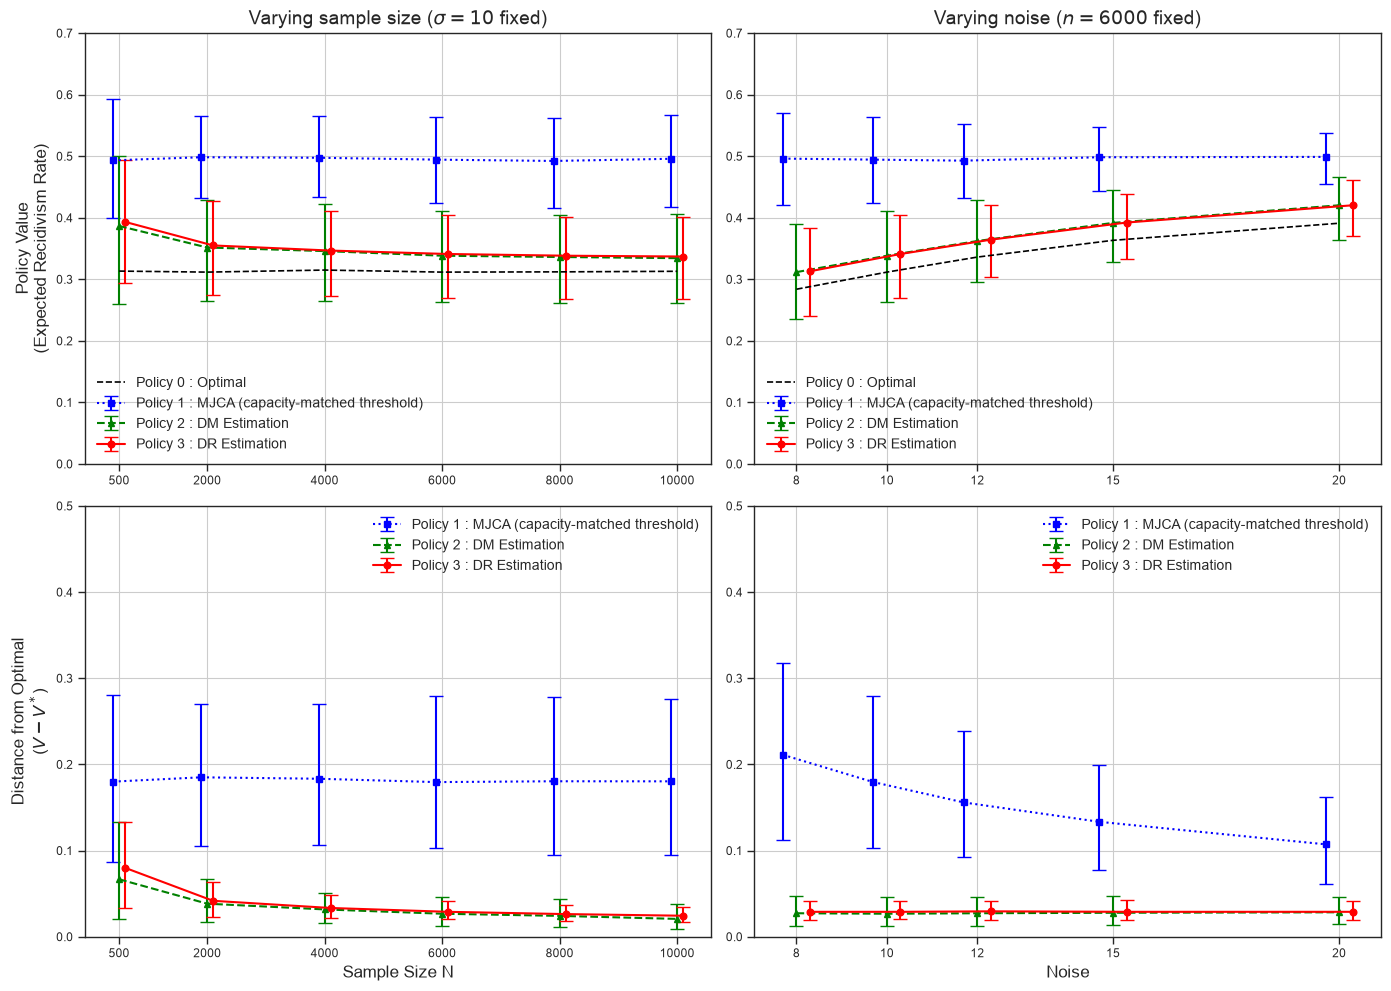

In [8]:
# @title 4-3. 図 S1: 論文 Fig. 4 と同じ形（上段: 方策価値、下段: 最適方策との差）
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
SPEC = [('MJCA', 'Policy 1 : MJCA (capacity-matched threshold)', 'blue', ':', 's'),
        ('DM', 'Policy 2 : DM Estimation', 'green', '--', '^'),
        ('DR-OPL', 'Policy 3 : DR Estimation', 'red', '-', 'o')]
def paper_style_figure(noise_levels, sigma_for_n, fname):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for col, (grid, levels, fixed, offset, title, xlabel) in enumerate([
            ('n', SAMPLE_SIZES, ('sigma', sigma_for_n), 100, f'Varying sample size ($\\sigma = {sigma_for_n}$ fixed)', 'Sample Size N'),
            ('sigma', noise_levels, ('n', 6000), 0.1 * (noise_levels[-1] - noise_levels[0]) / 4, 'Varying noise ($n = 6000$ fixed)', 'Noise')]):
        sub = res1[(res1[fixed[0]] == fixed[1]) & (res1[grid].isin(levels))]
        for row, (prefix, ylim, ylabel) in enumerate([('V_', (0.0, 0.7), 'Policy Value\n(Expected Recidivism Rate)'),
                                                     ('gap_', (0.0, 0.5), 'Distance from Optimal\n($V - V^*$)')]):
            ax = axes[row, col]
            for i, (p_, lab, c, ls, mk) in enumerate(SPEC):
                g = sub.groupby(grid)[f'{prefix}{p_}']
                med, lo, hi = g.median(), g.quantile(0.025), g.quantile(0.975)
                xs = np.array(med.index) + (i - 1) * offset
                ax.errorbar(xs, med.values, yerr=[med.values - lo.values, hi.values - med.values], marker=mk, color=c,
                            linestyle=ls, capsize=5, linewidth=1.5, label=lab)
            if prefix == 'V_':
                ax.plot(levels, sub.groupby(grid)['V_Optimal'].median().values, 'k--', label='Policy 0 : Optimal')
                ax.set_title(title, fontsize=14)
            ax.set_xticks(levels); ax.set_xticklabels(levels)
            ax.set_ylim(*ylim); ax.grid(True); ax.legend(fontsize=10, frameon=False)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=12)
            if row == 1:
                ax.set_xlabel(xlabel, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT / fname, dpi=300, bbox_inches='tight')
    plt.show()

# 元シミュレーションと同じ条件（再現）
paper_style_figure(NOISE_ORIG, 5, 'figS1a_policy_values_original_noise.png')
# 現実的なノイズ（σ = 10 が実データの予測の難しさ）
paper_style_figure(NOISE_REAL, SIGMA_REAL, 'figS1b_policy_values_realistic_noise.png')

,q_MJCA,q_DM0,q_DM1,p0_true,p1_true,r_obs,A
decile,,,,,,,
0,0.276,0.205,0.664,0.168,0.783,0.250,0.154
1,0.388,0.296,0.611,0.271,0.686,0.389,0.330
2,0.434,0.355,0.574,0.345,0.626,0.451,0.453
3,0.456,0.405,0.539,0.411,0.572,0.476,0.539
4,0.463,0.450,0.505,0.472,0.522,0.481,0.605
5,0.464,0.490,0.474,0.526,0.477,0.473,0.657
6,0.456,0.526,0.442,0.578,0.434,0.459,0.701
7,0.440,0.557,0.410,0.627,0.395,0.440,0.743
8,0.417,0.583,0.377,0.675,0.354,0.412,0.785


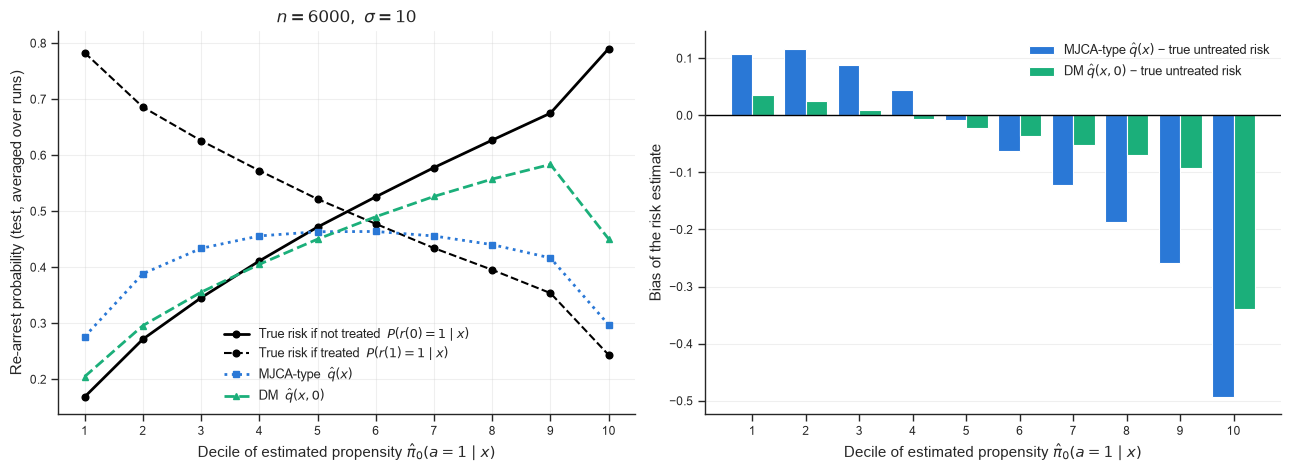

,q_MJCA,q_DM0,q_DM1,p0_true,p1_true,r_obs,A
decile,,,,,,,
0,0.220,0.117,0.781,0.083,0.888,0.193,0.154
1,0.355,0.212,0.697,0.184,0.779,0.358,0.332
2,0.415,0.290,0.635,0.278,0.693,0.437,0.454
3,0.444,0.364,0.574,0.371,0.613,0.468,0.539
4,0.452,0.433,0.517,0.458,0.536,0.473,0.604
5,0.447,0.497,0.459,0.540,0.463,0.458,0.659
6,0.432,0.554,0.407,0.615,0.399,0.435,0.703
7,0.407,0.605,0.355,0.684,0.337,0.406,0.743
8,0.373,0.649,0.307,0.748,0.283,0.367,0.784


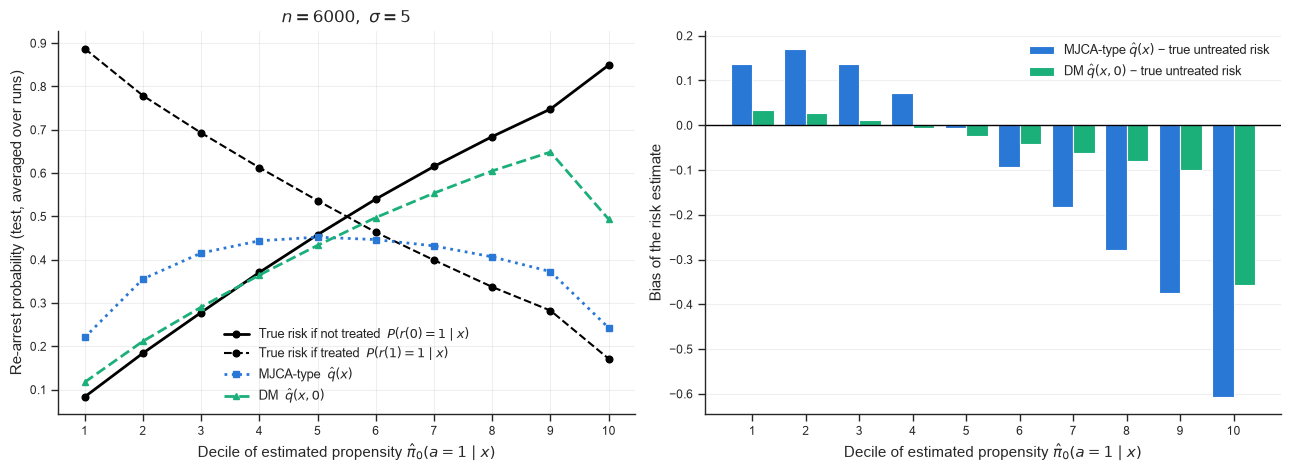

係数の比較（中央値。真の γ0 が大きい半分の変数で符号が逆になる割合と、真の γ0 との相関）


,signflip_MJCA,signflip_q0,corr_MJCA_gamma0,corr_q0_gamma0
sigma,,,,
5,0.464,0.107,-0.080,0.906
10,0.429,0.179,-0.018,0.885


In [9]:
# @title 4-4. 図 S2: MJCA のバイアスそのもの（n = 6,000。σ = 5 と σ = 10）
def bias_figure(sig, fname):
    diag_avg = pd.concat([d for s_, d in diag_list if s_ == sig]).groupby(level=0).mean()
    diag_avg.round(4).to_csv(OUT / f'table_stage1_bias_by_propensity_sigma{sig}.csv')
    display(diag_avg.round(3))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    x = diag_avg.index + 1
    ax = axes[0]
    ax.plot(x, diag_avg['p0_true'], 'k-', marker='o', lw=2, label='True risk if not treated  $P(r(0)=1\\mid x)$')
    ax.plot(x, diag_avg['p1_true'], 'k--', marker='o', lw=1.5, label='True risk if treated  $P(r(1)=1\\mid x)$')
    ax.plot(x, diag_avg['q_MJCA'], color=C_BLUE, ls=':', marker='s', lw=2, label='MJCA-type  $\\hat q(x)$')
    ax.plot(x, diag_avg['q_DM0'], color=C_AQUA, ls='--', marker='^', lw=2, label='DM  $\\hat q(x, 0)$')
    ax.set_xlabel('Decile of estimated propensity $\\hat\\pi_0(a=1\\mid x)$', fontsize=11)
    ax.set_ylabel('Re-arrest probability (test, averaged over runs)', fontsize=11)
    ax.set_title(f'$n = 6000,\\ \\sigma = {sig}$', fontsize=12)
    ax.set_xticks(x); ax.legend(fontsize=9, frameon=False); ax.grid(alpha=0.3); sns.despine(ax=ax)
    ax = axes[1]
    ax.bar(x - 0.2, diag_avg['q_MJCA'] - diag_avg['p0_true'], width=0.4, color=C_BLUE, label='MJCA-type $\\hat q(x)$ − true untreated risk')
    ax.bar(x + 0.2, diag_avg['q_DM0'] - diag_avg['p0_true'], width=0.4, color=C_AQUA, label='DM $\\hat q(x,0)$ − true untreated risk')
    ax.axhline(0, color='k', lw=1)
    ax.set_xlabel('Decile of estimated propensity $\\hat\\pi_0(a=1\\mid x)$', fontsize=11)
    ax.set_ylabel('Bias of the risk estimate', fontsize=11)
    ax.set_xticks(x); ax.legend(fontsize=9, frameon=False); ax.grid(axis='y', alpha=0.3); sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(OUT / fname, dpi=300, bbox_inches='tight')
    plt.show()

bias_figure(SIGMA_REAL, 'figS2_mjca_bias_by_propensity.png')
bias_figure(5, 'figS2_mjca_bias_by_propensity_sigma5.png')

coef_tab = (res1[res1.n.eq(6000) & res1.sigma.isin([5, SIGMA_REAL])]
            .groupby('sigma')[['signflip_MJCA', 'signflip_q0', 'corr_MJCA_gamma0', 'corr_q0_gamma0']].median().round(3))
coef_tab.to_csv(OUT / 'table_stage1_coefficients.csv')
print('係数の比較（中央値。真の γ0 が大きい半分の変数で符号が逆になる割合と、真の γ0 との相関）')
display(coef_tab)
d1 = res1[(res1.n == 6000) & (res1.sigma == SIGMA_REAL)]  # 段階 2 との比較の基準

## 5. 段階 2: 明示的な異質性と、SHAP による復元

処遇した場合の結果に $-\kappa\,h(x)$ を加える。$h$ は **若い（age_group が小さい）・MH/SA 条件あり・薬物関連の逮捕歴が多い** ほど大きく、$\text{SD}(\kappa h)=10$。$n=6{,}000$、$\sigma=10$（現実的なノイズ）。

cached: stage2_results.pkl


,"stage 1 (no explicit heterogeneity, sigma = 10)",stage 2 (explicit heterogeneity)
MJCA,"0.179 [0.103, 0.279]","0.263 [0.209, 0.336]"
MJCA (best thr),"0.156 [0.098, 0.238]","0.202 [0.154, 0.270]"
MJCA (thr 0.2),"0.191 [0.128, 0.271]","0.245 [0.187, 0.313]"
DM,"0.027 [0.013, 0.046]","0.022 [0.011, 0.036]"
DR-OPL,"0.029 [0.020, 0.042]","0.027 [0.018, 0.038]"
Observed (pi0),"0.098 [0.071, 0.141]","0.123 [0.099, 0.163]"


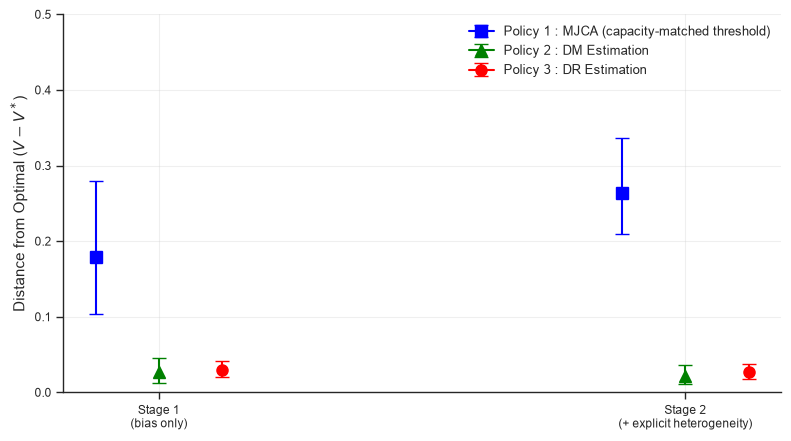

In [10]:
# @title 5-1. 実行
jobs2 = [(6000, SIGMA_REAL, rep) for rep in range(NUM_REPS_HET)]
res2 = cached(OUT / 'stage2_results.pkl', NUM_REPS_HET, ['n', 'sigma'], [(6000, SIGMA_REAL)])
if res2 is None:
    res2 = pd.DataFrame(Parallel(n_jobs=-1, batch_size=4)(
        delayed(run_once)(Z_ALL, A_ALL, BETA, n, s, rep, kappa=KAPPA_HET) for n, s, rep in tqdm(jobs2, dynamic_ncols=True)))
    res2.to_pickle(OUT / 'stage2_results.pkl')
for p_ in POLS:
    res2[f'gap_{p_}'] = res2[f'V_{p_}'] - res2['V_Optimal']
comp = pd.DataFrame({
    'stage 1 (no explicit heterogeneity, sigma = 10)': {p_: fmt(d1, f'gap_{p_}') for p_ in POLS},
    'stage 2 (explicit heterogeneity)': {p_: fmt(res2, f'gap_{p_}') for p_ in POLS}})
comp.to_csv(OUT / 'table_stage2_gap.csv')
display(comp)

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (p_, lab, c, ls, mk) in enumerate(SPEC):
    for j, (name, d_) in enumerate([('Stage 1', d1), ('Stage 2', res2)]):
        g = d_[f'gap_{p_}']
        ax.errorbar(j + (i - 1) * 0.12, g.median(), yerr=[[g.median() - g.quantile(0.025)], [g.quantile(0.975) - g.median()]],
                    marker=mk, color=c, capsize=5, lw=1.5, ms=8, label=lab if j == 0 else None)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Stage 1\n(bias only)', 'Stage 2\n(+ explicit heterogeneity)'])
ax.set_ylabel('Distance from Optimal ($V - V^*$)', fontsize=11); ax.set_ylim(0, 0.5)
ax.legend(fontsize=9, frameon=False); ax.grid(alpha=0.3); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT / 'figS4_stage2_policy_values.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# @title 5-2. SHAP: 真のベネフィット・DR-OPL・MJCA 型の比較（1 回分の学習済みモデル）
try:
    import shap
except ImportError:
    import subprocess as _sp
    _sp.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=True)
    import shap

gh_x, gh_w = np.polynomial.hermite_e.hermegauss(30)  # ε ~ N(0, σ²) の期待値（Gauss–Hermite）
gh_w = gh_w / gh_w.sum()

def group_of(c):
    return 'Residence PUMA' if c.startswith('puma_') else ('Prison offense' if c.startswith('offense_') else c)
groups = pd.Series([group_of(c) for c in X_POL], index=X_POL)

def shap_analysis(kappa, rep=0):
    one = run_once(Z_ALL, A_ALL, BETA, 6000, SIGMA_REAL, rep=rep, kappa=kappa, return_models=True)['models']

    def f_true_benefit(Zm):
        # 真のベネフィット E_ε[P(r(0)=1|x,ε) − P(r(1)=1|x,ε)]（処遇で再犯がどれだけ下がるか）
        b0 = (Zm @ one['gamma0'])[:, None]; b1 = (Zm @ one['gamma1'] - one['kappa'] * h_fn(Zm))[:, None]
        e_ = one['sigma'] * gh_x[None, :]
        return ((sigmoid(b0 + e_) - sigmoid(b1 + e_)) * gh_w[None, :]).sum(axis=1)

    def f_opl(Zm):
        with torch.no_grad():
            return one['net'](torch.tensor(Zm, dtype=torch.float)).numpy()[:, 1]

    def f_dm_benefit(Zm):
        q = lambda a: one['m_q'](np.column_stack([Zm, np.full(len(Zm), a)]))
        return q(0) - q(1)

    fns = {'True benefit': f_true_benefit, 'DR-OPL pi(1|x)': f_opl, 'DM benefit': f_dm_benefit,
           'MJCA risk q(x)': lambda Zm: one['m_mjca'](Zm)}
    rs = np.random.default_rng(SEED)
    Zx = one['Zte'][rs.choice(len(one['Zte']), 1000, replace=False)]
    Zb = one['Ztr'][rs.choice(len(one['Ztr']), 100, replace=False)]
    sv = {k: shap.explainers.Permutation(f, shap.maskers.Independent(Zb), seed=SEED)(Zx, max_evals=2 * Zx.shape[1] + 1).values
          for k, f in fns.items()}
    imp = pd.DataFrame({k: pd.DataFrame(v, columns=X_POL).T.groupby(groups).sum().T.abs().mean() for k, v in sv.items()})
    imp_share = imp / imp.sum()
    # 向き: 変数の値と SHAP 値の相関の符号（その変数が大きいほどスコアを上げるか下げるか）
    direction = pd.DataFrame({k: [np.corrcoef(Zx[:, j], v[:, j])[0, 1] if Zx[:, j].std() > 0 else 0 for j in range(len(X_POL))]
                              for k, v in sv.items()}, index=X_POL)
    truth_top = pd.Series(np.abs(sv['True benefit']).mean(axis=0), index=X_POL).sort_values(ascending=False).head(10).index
    dir_agree = {k: np.mean(np.sign(direction.loc[truth_top, k]) == np.sign(direction.loc[truth_top, 'True benefit'])) for k in fns}
    # 人ごとの順位相関: スコアと真のベネフィット
    tb = fns['True benefit'](Zx)
    person_corr = {k: pd.Series(fns[k](Zx)).corr(pd.Series(tb), method='spearman') for k in fns}
    return imp_share, direction, dir_agree, person_corr

shap_res = {k: shap_analysis(k) for k in [0.0, KAPPA_HET]}
imp_share, direction, dir_agree, person_corr = shap_res[KAPPA_HET]
imp_share.round(4).to_csv(OUT / 'table_stage2_shap_importance.csv')
direction.round(3).to_csv(OUT / 'table_stage2_shap_direction.csv')
summary_shap = pd.DataFrame({
    f'{lab}: person-level rank corr. with true benefit': pd.Series(shap_res[k][3]) for k, lab in [(0.0, 'stage 1'), (KAPPA_HET, 'stage 2')]} |
    {f'{lab}: direction agrees with truth (top-10 vars)': pd.Series(shap_res[k][2]) for k, lab in [(0.0, 'stage 1'), (KAPPA_HET, 'stage 2')]}).round(3)
summary_shap.to_csv(OUT / 'table_stage2_shap_summary.csv')
display(summary_shap)
het_share = pd.DataFrame({f'stage {i + 1}': shap_res[k][0].loc[list(HET_VARS)].sum() for i, k in enumerate([0.0, KAPPA_HET])}).round(3)
het_share.to_csv(OUT / 'table_stage2_het_vars_share.csv')
print('正解の異質性の 3 変数（age_group, Condition_MH_SA, Prior_Arrest_Episodes_Drug）の SHAP 重要度の合計シェア')
display(het_share)
display(imp_share.sort_values('True benefit', ascending=False).head(12).round(3))
display(direction.loc[list(HET_VARS)].round(3))

PermutationExplainer explainer:  66%|██████▋   | 665/1000 [00:00<?, ?it/s]

PermutationExplainer explainer:  67%|██████▋   | 673/1000 [00:10<00:04, 72.54it/s]

PermutationExplainer explainer:  68%|██████▊   | 681/1000 [00:10<00:04, 71.70it/s]

PermutationExplainer explainer:  69%|██████▉   | 689/1000 [00:10<00:04, 69.67it/s]

PermutationExplainer explainer:  70%|██████▉   | 697/1000 [00:10<00:04, 70.08it/s]

...

,stage 1: person-level rank corr. with true benefit,stage 2: person-level rank corr. with true benefit,stage 1: direction agrees with truth (top-10 vars),stage 2: direction agrees with truth (top-10 vars)
True benefit,1.000,1.000,1.0,1.0
DR-OPL pi(1|x),0.845,0.873,0.9,1.0
DM benefit,0.881,0.867,1.0,1.0
MJCA risk q(x),-0.214,-0.283,0.6,0.3


正解の異質性の 3 変数（age_group, Condition_MH_SA, Prior_Arrest_Episodes_Drug）の SHAP 重要度の合計シェア


,stage 1,stage 2
True benefit,0.298,0.485
DR-OPL pi(1|x),0.223,0.386
DM benefit,0.321,0.544
MJCA risk q(x),0.222,0.365


,True benefit,DR-OPL pi(1|x),DM benefit,MJCA risk q(x)
age_group,0.276,0.188,0.286,0.076
Prior_Arrest_Episodes_Drug,0.114,0.103,0.128,0.124
prison_years,0.096,0.081,0.104,0.030
Condition_MH_SA,0.095,0.095,0.130,0.165
Prison offense,0.068,0.049,0.032,0.060
Residence PUMA,0.043,0.065,0.028,0.049
Prior_Conviction_Episodes_PPViolationCharges,0.037,0.021,0.023,0.027
Condition_Cog_Ed,0.033,0.033,0.026,0.031
Prior_Conviction_Episodes_Drug,0.033,0.046,0.011,0.026
Prior_Arrest_Episodes_Felony,0.024,0.025,0.029,0.031


,True benefit,DR-OPL pi(1|x),DM benefit,MJCA risk q(x)
age_group,-0.994,-0.936,-0.972,-0.324
Condition_MH_SA,0.983,0.892,0.951,-0.952
Prior_Arrest_Episodes_Drug,0.988,0.899,0.938,-0.914


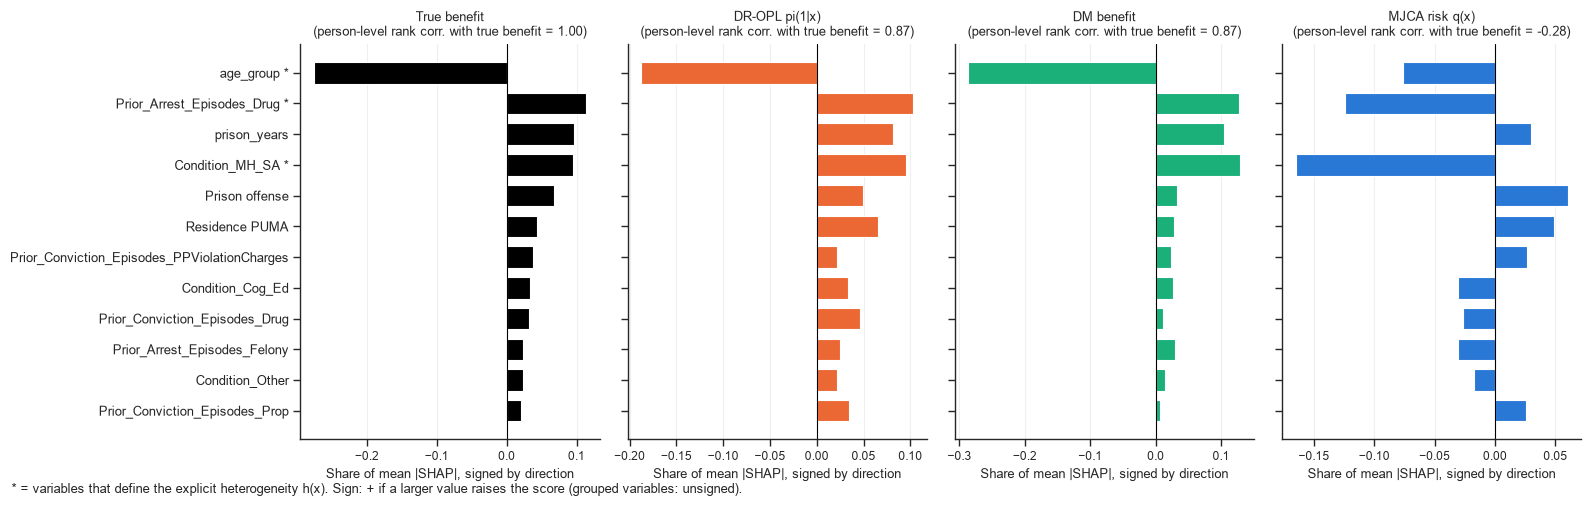

In [12]:
# @title 5-3. 図 S5: SHAP 重要度の比較（真のベネフィットの上位 12 変数）
top = imp_share['True benefit'].sort_values(ascending=False).head(12).index
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, (k, c) in zip(axes, [('True benefit', 'k'), ('DR-OPL pi(1|x)', C_ORANGE), ('DM benefit', C_AQUA), ('MJCA risk q(x)', C_BLUE)]):
    ax.barh(np.arange(len(top))[::-1], [imp_share.loc[t, k] * (np.sign(direction.loc[t, k]) if t in direction.index else 1) for t in top], color=c, height=0.7)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title(f'{k}\n(person-level rank corr. with true benefit = {person_corr[k]:.2f})', fontsize=9)
    ax.set_xlabel('Share of mean |SHAP|, signed by direction', fontsize=9); ax.grid(axis='x', alpha=0.3); sns.despine(ax=ax)
axes[0].set_yticks(np.arange(len(top))[::-1])
axes[0].set_yticklabels([f'{t} *' if t in HET_VARS else t for t in top], fontsize=9)
fig.text(0.01, 0.005, '* = variables that define the explicit heterogeneity h(x). Sign: + if a larger value raises the score (grouped variables: unsigned).', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'figS5_shap_recovery.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. アウトカムモデルの関数形の誤設定（計画 §9）

DR 推定量のバイアスは「傾向スコアの誤差 × アウトカムモデルの誤差」の積の形なので、アウトカムモデルにバイアスが残っても、傾向スコアが相対的にまともなら DM よりましになるはず。ここでは、アウトカムモデル（MJCA 型の $\hat q(x)$、DM の $\hat q(x,a)$、DR-OPL の補正項の $\hat q$）を **主効果のみのロジスティック回帰** にして関数形を誤設定にする（真の処遇効果は $x$ によって変わるが、主効果のモデルでは表せない）。傾向スコアは LightGBM のまま。データの乱数は §4 と同じ（対応のある比較）。

- 期待: LightGBM では DR-OPL ≈ DM ≫ MJCA 型、線形のアウトカムモデルでは DR-OPL > DM ≫ MJCA 型

In [13]:
# @title 6-1. 実行と比較
MIS_SIGMAS = [5, SIGMA_REAL]
res3 = cached(OUT / 'misspec_results.pkl', NUM_REPS, ['n', 'sigma'], [(6000, s) for s in MIS_SIGMAS])
if res3 is None:
    jobs3 = [(6000, s, rep) for s in MIS_SIGMAS for rep in range(NUM_REPS)]
    res3 = pd.DataFrame(Parallel(n_jobs=-1, batch_size=8)(
        delayed(run_once)(Z_ALL, A_ALL, BETA, n, s, rep, outcome_model='logit') for n, s, rep in tqdm(jobs3, dynamic_ncols=True)))
    res3.to_pickle(OUT / 'misspec_results.pkl')
for p_ in POLS:
    res3[f'gap_{p_}'] = res3[f'V_{p_}'] - res3['V_Optimal']

both = pd.concat([res1[(res1.n == 6000) & res1.sigma.isin(MIS_SIGMAS)].assign(outcome_model='LightGBM'),
                  res3.assign(outcome_model='Logistic (main effects)')], ignore_index=True)
rows = []
for (om, sg), g in both.groupby(['outcome_model', 'sigma']):
    d = g['V_DR-OPL'] - g['V_DM']
    rows.append({'outcome model': om, 'sigma': sg,
                 **{p_: fmt(g, f'gap_{p_}') for p_ in ['MJCA', 'MJCA (best thr)', 'DM', 'DR-OPL']},
                 'DR-OPL minus DM (median [2.5%, 97.5%])': f"{d.median():.3f} [{d.quantile(0.025):.3f}, {d.quantile(0.975):.3f}]",
                 'share of runs DR-OPL < DM': round((d < 0).mean(), 3),
                 'AUC q(x,a)': round(g['AUC_DM'].median(), 3)})
mis_tab = pd.DataFrame(rows)
mis_tab.to_csv(OUT / 'table_misspec_gap.csv', index=False)
display(mis_tab)

cached: misspec_results.pkl


,outcome model,sigma,MJCA,MJCA (best thr),DM,DR-OPL,"DR-OPL minus DM (median [2.5%, 97.5%])",share of runs DR-OPL < DM,"AUC q(x,a)"
0,LightGBM,5,"0.288 [0.151, 0.409]","0.236 [0.145, 0.340]","0.028 [0.014, 0.047]","0.029 [0.020, 0.041]","0.002 [-0.017, 0.016]",0.419,0.831
1,LightGBM,10,"0.179 [0.103, 0.279]","0.156 [0.098, 0.238]","0.027 [0.013, 0.046]","0.029 [0.020, 0.042]","0.003 [-0.017, 0.018]",0.397,0.706
2,Logistic (main effects),5,"0.269 [0.132, 0.427]","0.224 [0.119, 0.338]","0.252 [0.172, 0.353]","0.040 [0.027, 0.069]","-0.209 [-0.317, -0.123]",1.000,0.649
3,Logistic (main effects),10,"0.158 [0.077, 0.288]","0.140 [0.070, 0.232]","0.173 [0.112, 0.252]","0.039 [0.027, 0.061]","-0.133 [-0.214, -0.071]",1.000,0.606


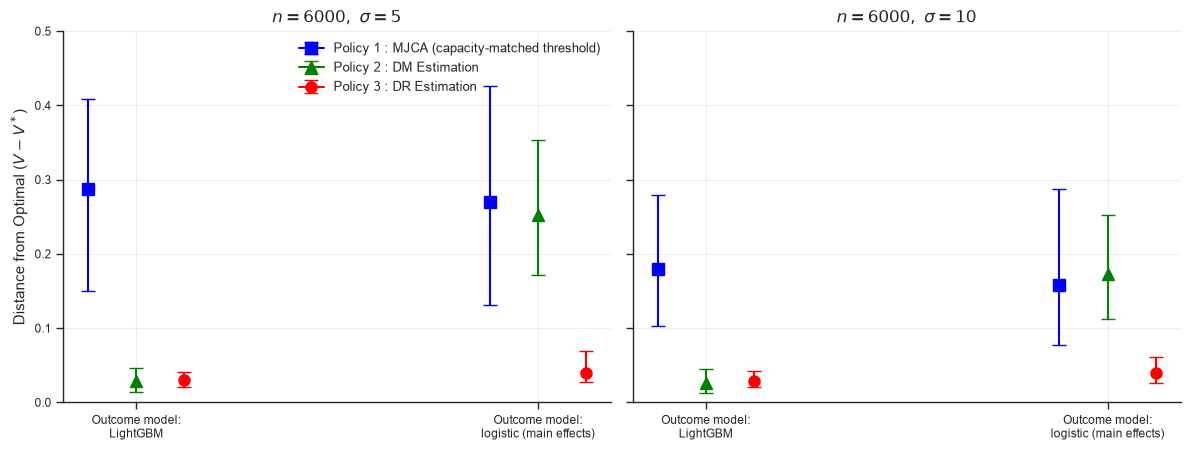

In [14]:
# @title 6-2. 図 S6: アウトカムモデルの関数形ごとの最適方策との差
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, sg in zip(axes, MIS_SIGMAS):
    for i, (p_, lab, c, ls, mk) in enumerate(SPEC):
        for j, om in enumerate(['LightGBM', 'Logistic (main effects)']):
            g = both[(both.outcome_model == om) & (both.sigma == sg)][f'gap_{p_}']
            ax.errorbar(j + (i - 1) * 0.12, g.median(), yerr=[[g.median() - g.quantile(0.025)], [g.quantile(0.975) - g.median()]],
                        marker=mk, color=c, capsize=5, lw=1.5, ms=8, label=lab if j == 0 else None)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Outcome model:\nLightGBM', 'Outcome model:\nlogistic (main effects)'])
    ax.set_title(f'$n = 6000,\\ \\sigma = {sg}$', fontsize=12)
    ax.set_ylim(0, 0.5); ax.grid(alpha=0.3); sns.despine(ax=ax)
axes[0].set_ylabel('Distance from Optimal ($V - V^*$)', fontsize=11)
axes[0].legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(OUT / 'figS6_outcome_model_misspecification.png', dpi=300, bbox_inches='tight')
plt.show()